# BENCHMARK 1.tpeanuts_vs_peanuts_performance
---
This notebook benchmarks execution time for `tpeanuts` and legacy `peanuts`. The sweep measures scaling with the energy-grid size and, for Earth-dependent stages, with the nadir-angle grid size.


## 1. Libraries

Imports for numerical work, plotting, timing, and both implementations.


In [1]:
from __future__ import annotations

import gc
import math
import os
import sys
import time
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


from tpeanuts.util.notebooks import find_repo_root, save_and_show, save_figure, show_figure
from tpeanuts.util.type import to_numpy
HERE = Path.cwd().resolve()
PACKAGE_DIR = find_repo_root(HERE, folder="analysis")
print(f"PACKAGE_DIR = {PACKAGE_DIR}")

plt.rcParams.update({"figure.figsize": (8.0, 4.8), "axes.grid": True, "grid.alpha": 0.3})
torch.set_printoptions(precision=6, sci_mode=True, linewidth=160)
np.set_printoptions(precision=6, suppress=False, linewidth=160)

from tpeanuts.core.pmns import PMNS
from tpeanuts.core.probabilities import apply_probability_matrix_to_flux
from tpeanuts.io.io_earth import load_earth_density_from_csv
from tpeanuts.earth.probabilities import pearth
from tpeanuts.flux_propagation.pipeline_legacypeanuts import _ensure_legacy_default_data_aliases
from tpeanuts.solar.probabilities import psolar, solar_flux_mass
from tpeanuts.solar.profiles import load_default_solar_profile
from tpeanuts.solar.validation import legacy_modules
from tpeanuts.vacuum.probabilities import vacuum_probability_matrix

_ensure_legacy_default_data_aliases()

from peanuts.earth import Pearth as legacy_pearth
from peanuts.earth import earthdensity as LegacyEarthDensity
from peanuts.pmns import PMNS as LegacyPMNS
from peanuts.vacuum import Pvacuum as legacy_pvacuum

print(f"Torch version   : {torch.__version__}")


PACKAGE_DIR = G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts
Warning!: Python module pyslha not found, disabling slha reading routines
Torch version   : 2.3.1


## 2. Configuration

The benchmark uses fixed oscillation parameters and centralizes the timing grid sizes. Increase `ENERGY_GRID_SIZES`, `NADIR_GRID_SIZES`, or `TIMING_REPEATS` for longer production runs.


### 2.1 Paths

Input data are read from the repository; timing CSV files and plots are written under `1.tpeanuts_vs_peanuts_performance`.


In [2]:
DEFAULT_OUTPUT_ROOT = Path(r"V:\output")
OUTPUT_ROOT = Path(os.environ.get("TPEANUTS_OUTPUT_ROOT", DEFAULT_OUTPUT_ROOT))

OUTPUT_DATA_ROOT = Path(OUTPUT_ROOT / "data")
OUTPUT_ANALYSIS_ROOT = Path(OUTPUT_ROOT / "analysis")
OUTPUT_BENCHMARK_ROOT = Path(OUTPUT_ROOT / "benchmark")
OUTPUT_TEST_ROOT = Path(OUTPUT_ROOT / "test")

OUTPUT_DATA_ATMOSPHERE = Path(OUTPUT_DATA_ROOT / "atmosphere")
OUTPUT_DATA_SOLAR = Path(OUTPUT_DATA_ROOT / "solar")
OUTPUT_DATA_EXTERNAL = Path(OUTPUT_DATA_ROOT / "external")

OUTPUT_ANALYSIS_ATMOSPHERE = Path(OUTPUT_ANALYSIS_ROOT / "atmosphere")
OUTPUT_ANALYSIS_SOLAR = Path(OUTPUT_ANALYSIS_ROOT / "solar")
OUTPUT_ANALYSIS_EXTERNAL = Path(OUTPUT_ANALYSIS_ROOT / "external")

OUTPUT_DATA_MCEQ = Path(OUTPUT_DATA_ROOT / "mceq")
OUTPUT_DATA_HONDA = Path(OUTPUT_DATA_ROOT / "honda")

OUTPUT_DIR = OUTPUT_BENCHMARK_ROOT / "1_tpeanuts_vs_peanuts_performance"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

DATA_DIR = Path(PACKAGE_DIR / "data")
LEGACY_DATA_DIR = Path(DATA_DIR / "peanuts")

EARTH_DENSITY_TPEANUTS = str( DATA_DIR / "density" / "earth_density.csv" )
EARTH_DENSITY_LEGACY = str( LEGACY_DATA_DIR / "earth_density.csv" )

SHOW_PLOTS = True

print("Legacy Data Dir :", LEGACY_DATA_DIR)
print("Output root     :", OUTPUT_ROOT)
print("Output directory:", OUTPUT_DIR)



Legacy Data Dir : G:\Mi unidad\03.Codigo\034.TFM.UV\Tpeanuts\data\peanuts
Output root     : V:\output
Output directory: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance


### 2.2 Parameters

These values define the physics setup, timing repetitions, and grid sweeps.


In [3]:
DEVICE = torch.device("cpu")
DTYPE = torch.float64

THETA12 = 0.59
THETA13 = 0.15
THETA23 = 0.78
DELTA_CP = 1.20
DM21_EV2 = 7.42e-5
DM3L_EV2 = 2.517e-3

pmns = PMNS(THETA12, THETA13, THETA23, DELTA_CP, device=DEVICE, real_dtype=DTYPE)
legacy_pmns = LegacyPMNS(THETA12, THETA13, THETA23, DELTA_CP)

ENERGY_GRID_SIZES = [4, 8, 16, 32, 64, 128, 256]
NADIR_GRID_SIZES = [4, 8, 16, 32, 64,128,256]
TIMING_REPEATS = 2
TIMING_WARMUPS = 1

EARTH_METHOD = "analytical"  # "analytical" or "numerical" 
LEGACY_EARTH_MODE = EARTH_METHOD
EARTH_NUMERICAL_STEPS = 160
EARTH_ODE_METHOD = "midpoint"

EARTH_DEPTH_M = 0.0
SOLAR_DETECTOR_DEPTH_M = 1000.0
SOLAR_SOURCE = "8B"
VACUUM_BASELINE_KM = 1300.0

MASS_WEIGHTS = torch.tensor([0.20, 0.30, 0.50], dtype=DTYPE, device=DEVICE)
MASS_WEIGHTS_NP = np.array([0.20, 0.30, 0.50], dtype=np.float64)

print("Performance benchmark parameters loaded.")


Performance benchmark parameters loaded.


In [4]:
earth_density_t = load_earth_density_from_csv(str(EARTH_DENSITY_TPEANUTS), tabulated_density=False, device=DEVICE, dtype=DTYPE)
earth_density_l = LegacyEarthDensity(density_file=str(EARTH_DENSITY_LEGACY), tabulated_density=False)
solar_profile = load_default_solar_profile(device=DEVICE, dtype=DTYPE)
legacy_pmns_module, legacy_solar_module = legacy_modules()
legacy_model = legacy_solar_module.SolarModel(
    solar_model_file=str(LEGACY_DATA_DIR / "nudistr_b16_agss09.dat"),
    flux_file=str(LEGACY_DATA_DIR / "fluxes_b16.dat"),
    spectrum_files={
        "8B": str(LEGACY_DATA_DIR / "8B_shape_Ortiz_et_al.csv"),
        "hep": str(LEGACY_DATA_DIR / "hep_shape.csv"),
        "pp": str(LEGACY_DATA_DIR / "pp_shape.csv"),
        "17F": str(LEGACY_DATA_DIR / "f17_shape.csv"),
        "7Beground": str(LEGACY_DATA_DIR / "be7ground_shape.csv"),
        "7Beexcited": str(LEGACY_DATA_DIR / "be7excited_shape.csv"),
        "13N": str(LEGACY_DATA_DIR / "n13_shape.csv"),
        "15O": str(LEGACY_DATA_DIR / "o15_shape.csv"),
    },
)
legacy_pmns_solar = legacy_pmns_module.PMNS(THETA12, THETA13, THETA23, DELTA_CP)
print("Shared density and solar models loaded.")


Shared density and solar models loaded.


In [5]:
def energy_grid(n, *, solar=True):
    if solar:
        return torch.linspace(0.5, 15.0, int(n), dtype=DTYPE, device=DEVICE)
    return torch.logspace(
        torch.log10(torch.tensor(100.0, dtype=DTYPE)),
        torch.log10(torch.tensor(2.0e4, dtype=DTYPE)),
        int(n),
        dtype=DTYPE,
        device=DEVICE,
    )


def nadir_grid(n):
    return torch.linspace(0.05, math.pi - 0.05, int(n), dtype=DTYPE, device=DEVICE)


def synthetic_flux(E_MeV):
    x = E_MeV / 1000.0
    return torch.stack([
        1.00e2 * x.pow(-2.15) * torch.exp(-E_MeV / 5.0e4),
        2.50e2 * x.pow(-2.05) * torch.exp(-E_MeV / 6.0e4),
        1.50e1 * x.pow(-2.00) * torch.exp(-E_MeV / 7.0e4),
    ], dim=-1)


def solar_source_spectrum(E_MeV):
    E = torch.as_tensor(E_MeV, dtype=DTYPE, device=DEVICE)
    shape = torch.clamp(E * (16.0 - E), min=0.0) ** 2
    return shape / torch.max(shape).clamp_min(1.0e-30)


def timed_call(func, repeats=TIMING_REPEATS, warmups=TIMING_WARMUPS):
    for _ in range(warmups):
        func()
    times = []
    for _ in range(repeats):
        gc.collect()
        t0 = time.perf_counter()
        func()
        times.append(time.perf_counter() - t0)
    return min(times), float(np.mean(times)), float(np.std(times))


def benchmark_pair(section, ne, neta, tpeanuts_func, legacy_func):
    t_best, t_mean, t_std = timed_call(tpeanuts_func)
    l_best, l_mean, l_std = timed_call(legacy_func)
    speedup = l_best / max(t_best, 1.0e-15)
    print(f"{section:34s} | NE={ne:4d} | Neta={str(neta):>4s} | t={t_best:.4e}s | legacy={l_best:.4e}s | speedup={speedup:.2f}x")
    return {
        "section": section,
        "n_energy": int(ne),
        "n_nadir": None if neta is None else int(neta),
        "tpeanuts_best_s": t_best,
        "legacy_best_s": l_best,
        "tpeanuts_mean_s": t_mean,
        "legacy_mean_s": l_mean,
        "tpeanuts_std_s": t_std,
        "legacy_std_s": l_std,
        "speedup_legacy_over_tpeanuts": speedup,
    }


def save_results(df, name):
    path = OUTPUT_DIR / f"{name}.csv"
    df.to_csv(path, index=False)
    print(f"Saved timing table: {path}")


def plot_energy_scaling(df, title, filename):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))
    axes[0].loglog(df["n_energy"], df["tpeanuts_best_s"], marker="o", label="tpeanuts")
    axes[0].loglog(df["n_energy"], df["legacy_best_s"], marker="x", label="legacy peanuts")
    axes[0].set_xlabel("Energy-grid size")
    axes[0].set_ylabel("Best time [s]")
    axes[0].set_title(title)
    axes[0].legend()
    axes[1].semilogx(df["n_energy"], df["speedup_legacy_over_tpeanuts"], marker="o")
    axes[1].axhline(1.0, color="black", lw=1.0, alpha=0.5)
    axes[1].set_xlabel("Energy-grid size")
    axes[1].set_ylabel("legacy time / tpeanuts time")
    axes[1].set_title("Speedup")
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


def plot_heatmap(df, title, filename):
    pivot = df.pivot(index="n_nadir", columns="n_energy", values="speedup_legacy_over_tpeanuts")
    fig, ax = plt.subplots(figsize=(7.5, 5.5))
    im = ax.imshow(pivot.values, origin="lower", aspect="auto")
    ax.set_xticks(np.arange(len(pivot.columns)))
    ax.set_xticklabels([str(v) for v in pivot.columns])
    ax.set_yticks(np.arange(len(pivot.index)))
    ax.set_yticklabels([str(v) for v in pivot.index])
    ax.set_xlabel("Energy-grid size")
    ax.set_ylabel("Nadir-grid size")
    ax.set_title(title)
    fig.colorbar(im, ax=ax, label="legacy time / tpeanuts time")
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


def torch_pearth_probability(state, E_MeV, eta, depth_m, *, massbasis=True):
    E_t = torch.as_tensor(E_MeV, device=DEVICE, dtype=DTYPE)
    eta_t = torch.as_tensor(eta, device=DEVICE, dtype=DTYPE)
    state_t = torch.as_tensor(state, device=DEVICE)
    if EARTH_METHOD == "analytical":
        return pearth(
            nustate=state_t,
            density=earth_density_t,
            pmns=pmns,
            dm21_eV2=DM21_EV2,
            dm3l_eV2=DM3L_EV2,
            E_MeV=E_t,
            eta=eta_t,
            depth_m=depth_m,
            method="analytical",
            massbasis=massbasis,
            device=DEVICE,
            dtype=DTYPE,
        )
    if EARTH_METHOD == "numerical":
        E_b, eta_b = torch.broadcast_tensors(E_t, eta_t)
        values = []
        for energy_value, eta_value in zip(E_b.reshape(-1), eta_b.reshape(-1)):
            values.append(pearth(
                nustate=state_t,
                density=earth_density_t,
                pmns=pmns,
                dm21_eV2=DM21_EV2,
                dm3l_eV2=DM3L_EV2,
                E_MeV=energy_value,
                eta=eta_value,
                depth_m=depth_m,
                method="numerical",
                massbasis=massbasis,
                nsteps=EARTH_NUMERICAL_STEPS,
                ode_method=EARTH_ODE_METHOD,
                device=DEVICE,
                dtype=DTYPE,
            ))
        return torch.stack(values, dim=0).reshape(*E_b.shape, 3)
    raise ValueError("EARTH_METHOD must be analytical or numerical.")


def legacy_vacuum_matrix(E, L_km):
    E_np = to_numpy(E).reshape(-1)
    matrix = np.empty((len(E_np), 3, 3))
    for i, energy in enumerate(E_np):
        for alpha in range(3):
            matrix[i, :, alpha] = legacy_pvacuum(np.eye(3)[alpha], legacy_pmns, DM21_EV2, DM3L_EV2, float(energy), L_km, massbasis=False)
    return matrix


def tpeanuts_solar_mass(E):
    return solar_flux_mass(pmns.theta12, pmns.theta13, DM21_EV2, DM3L_EV2, E, solar_profile.radius, solar_profile.density, solar_profile.production_fraction(SOLAR_SOURCE))


def legacy_solar_mass(E):
    return np.stack([
        legacy_solar_module.solar_flux_mass(
            legacy_pmns_solar.theta12, legacy_pmns_solar.theta13, DM21_EV2, DM3L_EV2, float(energy),
            legacy_model.radius(), legacy_model.density(), legacy_model.fraction(SOLAR_SOURCE)
        )
        for energy in to_numpy(E)
    ])


def plot_speedup_cross_sections(df, title, filename):
    """Plot speedup vs energy at fixed nadir sizes and vs nadir size at fixed energy sizes."""
    fig, axes = plt.subplots(1, 2, figsize=(13, 4.8))

    for neta in sorted(df["n_nadir"].dropna().unique()):
        subset = df[df["n_nadir"] == neta].sort_values("n_energy")
        axes[0].semilogx(
            subset["n_energy"],
            subset["speedup_legacy_over_tpeanuts"],
            marker="o",
            label=f"Nadir grid={int(neta)}",
        )

    for ne in sorted(df["n_energy"].dropna().unique()):
        subset = df[df["n_energy"] == ne].sort_values("n_nadir")
        axes[1].semilogx(
            subset["n_nadir"],
            subset["speedup_legacy_over_tpeanuts"],
            marker="o",
            label=f"Energy grid={int(ne)}",
        )

    axes[0].axhline(1.0, color="black", lw=1.0, alpha=0.5)
    axes[1].axhline(1.0, color="black", lw=1.0, alpha=0.5)
    axes[0].set_xlabel("Energy-grid size")
    axes[0].set_ylabel("legacy time / tpeanuts time")
    axes[0].set_title("Speedup vs energy grid")
    axes[1].set_xlabel("Nadir-grid size")
    axes[1].set_ylabel("legacy time / tpeanuts time")
    axes[1].set_title("Speedup vs nadir grid")
    axes[0].legend(fontsize=8)
    axes[1].legend(fontsize=8)
    fig.suptitle(title)
    fig.tight_layout()
    save_and_show(filename, fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)


## 3. Vacuum Propagation

Vacuum propagation depends on the energy grid for a fixed baseline.


### 3.1 Probability Timing

This subsection times probability calculations as the energy grid grows.


vacuum probabilities               | NE=   4 | Neta=None | t=1.0513e-03s | legacy=7.7290e-04s | speedup=0.74x
vacuum probabilities               | NE=   8 | Neta=None | t=1.0526e-03s | legacy=1.4380e-03s | speedup=1.37x
vacuum probabilities               | NE=  16 | Neta=None | t=1.0566e-03s | legacy=2.3673e-03s | speedup=2.24x
vacuum probabilities               | NE=  32 | Neta=None | t=1.1934e-03s | legacy=4.7839e-03s | speedup=4.01x
vacuum probabilities               | NE=  64 | Neta=None | t=1.2357e-03s | legacy=8.6107e-03s | speedup=6.97x
vacuum probabilities               | NE= 128 | Neta=None | t=1.4178e-03s | legacy=1.7245e-02s | speedup=12.16x
vacuum probabilities               | NE= 256 | Neta=None | t=1.1963e-03s | legacy=3.3921e-02s | speedup=28.35x


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,vacuum probabilities,4,None,0.001051,0.000773,0.001085,0.000877,0.000034,0.000104,0.735185
1,vacuum probabilities,8,None,0.001053,0.001438,0.001231,0.003273,0.000179,0.001835,1.366141
2,vacuum probabilities,16,None,0.001057,0.002367,0.001473,0.002502,0.000416,0.000135,2.240488
3,vacuum probabilities,32,None,0.001193,0.004784,0.001896,0.005619,0.000703,0.000835,4.008631
4,vacuum probabilities,64,None,0.001236,0.008611,0.001748,0.008737,0.000512,0.000126,6.968277
5,vacuum probabilities,128,None,0.001418,0.017245,0.001771,0.017433,0.000353,0.000188,12.163281
6,vacuum probabilities,256,None,0.001196,0.033921,0.002126,0.034458,0.000930,0.000537,28.354927


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\vacuum_probability_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\vacuum_probability_timing.png


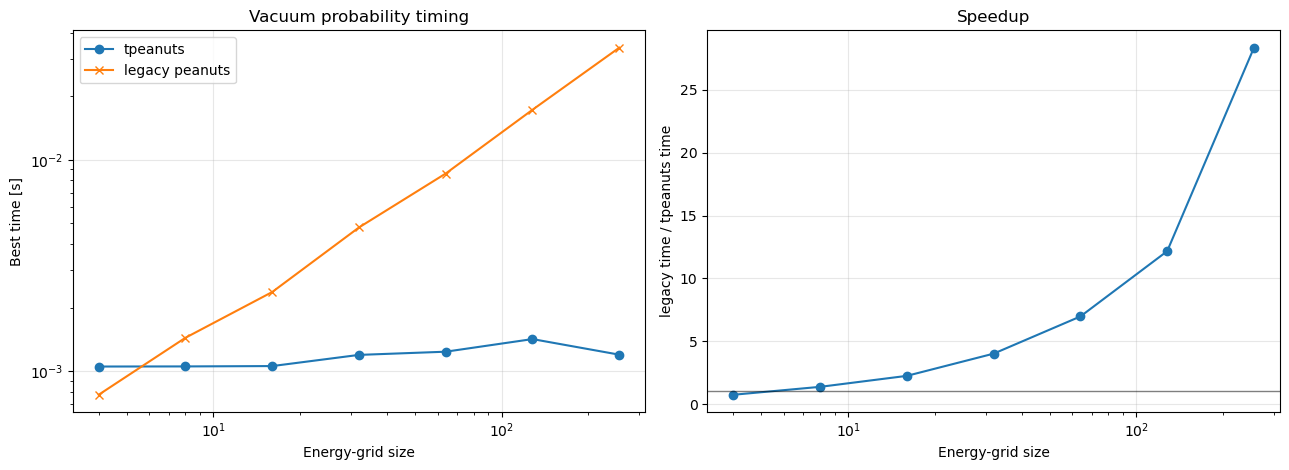

In [6]:
vacuum_probability_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=False)
    vacuum_probability_records.append(benchmark_pair(
        "vacuum probabilities", ne, None,
        lambda E=E: vacuum_probability_matrix(pmns, DM21_EV2, DM3L_EV2, E, VACUUM_BASELINE_KM, device=DEVICE, dtype=DTYPE),
        lambda E=E: legacy_vacuum_matrix(E, VACUUM_BASELINE_KM),
    ))
vacuum_probability_df = pd.DataFrame(vacuum_probability_records)
display(vacuum_probability_df)
save_results(vacuum_probability_df, "vacuum_probability_timing")
plot_energy_scaling(vacuum_probability_df, "Vacuum probability timing", "vacuum_probability_timing.png")


### 3.2 Flux Timing

This subsection times probability construction plus application to a representative flux spectrum.


vacuum flux                        | NE=   4 | Neta=None | t=1.2318e-03s | legacy=8.0590e-04s | speedup=0.65x
vacuum flux                        | NE=   8 | Neta=None | t=1.2128e-03s | legacy=1.3245e-03s | speedup=1.09x
vacuum flux                        | NE=  16 | Neta=None | t=1.0790e-03s | legacy=2.3590e-03s | speedup=2.19x
vacuum flux                        | NE=  32 | Neta=None | t=1.1960e-03s | legacy=4.3884e-03s | speedup=3.67x
vacuum flux                        | NE=  64 | Neta=None | t=1.2166e-03s | legacy=8.6169e-03s | speedup=7.08x
vacuum flux                        | NE= 128 | Neta=None | t=1.2454e-03s | legacy=1.6725e-02s | speedup=13.43x
vacuum flux                        | NE= 256 | Neta=None | t=1.6252e-03s | legacy=3.3707e-02s | speedup=20.74x


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,vacuum flux,4,None,0.001232,0.000806,0.001525,0.000993,0.000293,0.000187,0.654246
1,vacuum flux,8,None,0.001213,0.001325,0.001380,0.001327,0.000167,0.000002,1.092101
2,vacuum flux,16,None,0.001079,0.002359,0.001513,0.002365,0.000434,0.000006,2.186284
3,vacuum flux,32,None,0.001196,0.004388,0.001361,0.004434,0.000165,0.000046,3.669231
4,vacuum flux,64,None,0.001217,0.008617,0.001662,0.008714,0.000445,0.000097,7.082772
5,vacuum flux,128,None,0.001245,0.016725,0.001807,0.016876,0.000562,0.000151,13.429742
6,vacuum flux,256,None,0.001625,0.033707,0.001728,0.033845,0.000103,0.000139,20.739970


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\vacuum_flux_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\vacuum_flux_timing.png


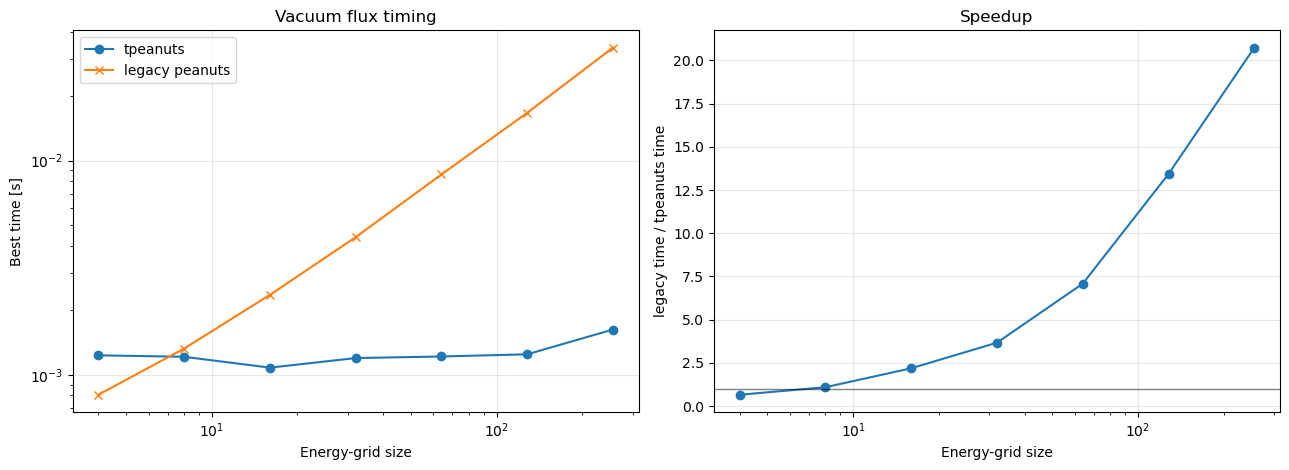

In [7]:
vacuum_flux_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=False)
    flux_t = synthetic_flux(E)
    flux_l = to_numpy(flux_t)
    vacuum_flux_records.append(benchmark_pair(
        "vacuum flux", ne, None,
        lambda E=E, flux_t=flux_t: apply_probability_matrix_to_flux(vacuum_probability_matrix(pmns, DM21_EV2, DM3L_EV2, E, VACUUM_BASELINE_KM, device=DEVICE, dtype=DTYPE), flux_t),
        lambda E=E, flux_l=flux_l: np.einsum("eba,ea->eb", legacy_vacuum_matrix(E, VACUUM_BASELINE_KM), flux_l),
    ))
vacuum_flux_df = pd.DataFrame(vacuum_flux_records)
display(vacuum_flux_df)
save_results(vacuum_flux_df, "vacuum_flux_timing")
plot_energy_scaling(vacuum_flux_df, "Vacuum flux timing", "vacuum_flux_timing.png")


## 4. Solar Production

Solar production is timed for one source over increasing energy-grid sizes.


### 4.1 Probability Timing

This subsection times probability calculations as the energy grid grows.


solar probabilities                | NE=   4 | Neta=None | t=2.9304e-03s | legacy=8.0350e-04s | speedup=0.27x
solar probabilities                | NE=   8 | Neta=None | t=4.3756e-03s | legacy=1.4666e-03s | speedup=0.34x
solar probabilities                | NE=  16 | Neta=None | t=5.3964e-03s | legacy=2.6881e-03s | speedup=0.50x
solar probabilities                | NE=  32 | Neta=None | t=7.5563e-03s | legacy=4.7021e-03s | speedup=0.62x
solar probabilities                | NE=  64 | Neta=None | t=1.4220e-02s | legacy=9.3173e-03s | speedup=0.66x
solar probabilities                | NE= 128 | Neta=None | t=1.6027e-02s | legacy=1.9577e-02s | speedup=1.22x
solar probabilities                | NE= 256 | Neta=None | t=2.0814e-02s | legacy=3.7631e-02s | speedup=1.81x


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar probabilities,4,None,0.002930,0.000804,0.003022,0.000827,0.000092,0.000024,0.274195
1,solar probabilities,8,None,0.004376,0.001467,0.004720,0.001485,0.000344,0.000018,0.335177
2,solar probabilities,16,None,0.005396,0.002688,0.005832,0.002769,0.000436,0.000080,0.498128
3,solar probabilities,32,None,0.007556,0.004702,0.008083,0.004993,0.000527,0.000291,0.622275
4,solar probabilities,64,None,0.014220,0.009317,0.014350,0.009536,0.000130,0.000218,0.655207
5,solar probabilities,128,None,0.016027,0.019577,0.016316,0.020030,0.000289,0.000453,1.221482
6,solar probabilities,256,None,0.020814,0.037631,0.027726,0.037756,0.006912,0.000125,1.807948


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_probability_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_probability_timing.png


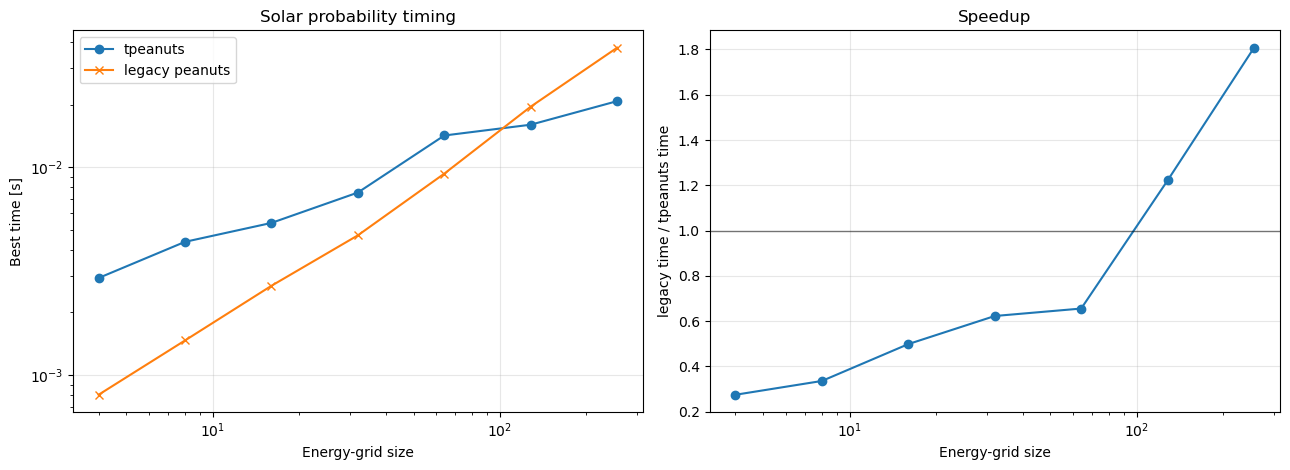

In [8]:
solar_probability_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=True)
    solar_probability_records.append(benchmark_pair(
        "solar probabilities", ne, None,
        lambda E=E: psolar(pmns, DM21_EV2, DM3L_EV2, E, solar_profile.radius, solar_profile.density, solar_profile.production_fraction(SOLAR_SOURCE)),
        lambda E=E: np.stack([
            legacy_solar_module.Psolar(legacy_pmns_solar, DM21_EV2, DM3L_EV2, float(energy), legacy_model.radius(), legacy_model.density(), legacy_model.fraction(SOLAR_SOURCE))
            for energy in to_numpy(E)
        ]),
    ))
solar_probability_df = pd.DataFrame(solar_probability_records)
display(solar_probability_df)
save_results(solar_probability_df, "solar_probability_timing")
plot_energy_scaling(solar_probability_df, "Solar probability timing", "solar_probability_timing.png")


### 4.2 Flux Timing

This subsection times probability construction plus application to a representative flux spectrum.


solar flux                         | NE=   4 | Neta=None | t=2.3063e-03s | legacy=7.3910e-04s | speedup=0.32x
solar flux                         | NE=   8 | Neta=None | t=2.7165e-03s | legacy=1.2811e-03s | speedup=0.47x
solar flux                         | NE=  16 | Neta=None | t=4.9669e-03s | legacy=2.3665e-03s | speedup=0.48x
solar flux                         | NE=  32 | Neta=None | t=7.5986e-03s | legacy=4.2371e-03s | speedup=0.56x
solar flux                         | NE=  64 | Neta=None | t=9.7034e-03s | legacy=8.8170e-03s | speedup=0.91x
solar flux                         | NE= 128 | Neta=None | t=1.5863e-02s | legacy=1.6574e-02s | speedup=1.04x
solar flux                         | NE= 256 | Neta=None | t=1.8630e-02s | legacy=3.5163e-02s | speedup=1.89x


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar flux,4,None,0.002306,0.000739,0.002386,0.000756,0.000080,0.000017,0.320470
1,solar flux,8,None,0.002717,0.001281,0.003502,0.001289,0.000785,0.000007,0.471599
2,solar flux,16,None,0.004967,0.002366,0.005780,0.002384,0.000813,0.000018,0.476454
3,solar flux,32,None,0.007599,0.004237,0.007851,0.004328,0.000252,0.000090,0.557616
4,solar flux,64,None,0.009703,0.008817,0.010289,0.008831,0.000586,0.000014,0.908651
5,solar flux,128,None,0.015863,0.016574,0.015869,0.017285,0.000006,0.000712,1.044757
6,solar flux,256,None,0.018630,0.035163,0.022568,0.036691,0.003938,0.001528,1.887446


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_flux_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_flux_timing.png


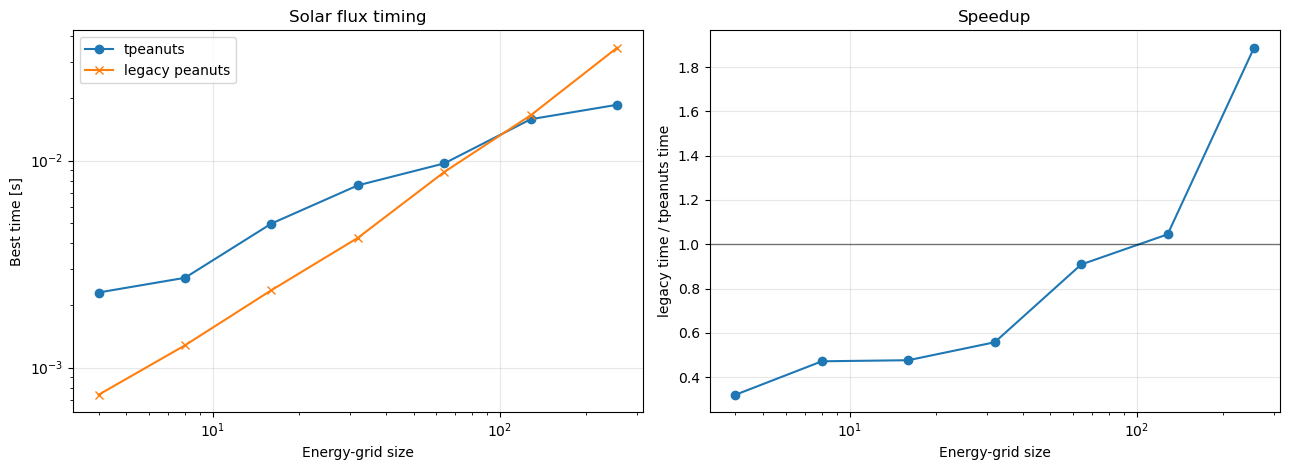

In [9]:
solar_flux_records = []
for ne in ENERGY_GRID_SIZES:
    E = energy_grid(ne, solar=True)
    spectrum_t = solar_source_spectrum(E)
    spectrum_l = to_numpy(spectrum_t)
    solar_flux_records.append(benchmark_pair(
        "solar flux", ne, None,
        lambda E=E, spectrum_t=spectrum_t: tpeanuts_solar_mass(E) * spectrum_t[:, None],
        lambda E=E, spectrum_l=spectrum_l: legacy_solar_mass(E) * spectrum_l[:, None],
    ))
solar_flux_df = pd.DataFrame(solar_flux_records)
display(solar_flux_df)
save_results(solar_flux_df, "solar_flux_timing")
plot_energy_scaling(solar_flux_df, "Solar flux timing", "solar_flux_timing.png")


## 5. Earth Propagation to the Detector

Earth propagation is timed over both energy and nadir-angle grids.


### 5.1 Probability Timing

This subsection times Earth probabilities for an incoherent mass-basis input.


earth probabilities                | NE=   4 | Neta=   4 | t=1.0132e-02s | legacy=1.0006e-03s | speedup=0.10x
earth probabilities                | NE=   4 | Neta=   8 | t=1.0670e-02s | legacy=1.7722e-03s | speedup=0.17x
earth probabilities                | NE=   4 | Neta=  16 | t=1.2919e-02s | legacy=3.2109e-03s | speedup=0.25x
earth probabilities                | NE=   4 | Neta=  32 | t=1.4995e-02s | legacy=6.2521e-03s | speedup=0.42x
earth probabilities                | NE=   4 | Neta=  64 | t=1.7947e-02s | legacy=1.1868e-02s | speedup=0.66x
earth probabilities                | NE=   4 | Neta= 128 | t=2.7720e-02s | legacy=2.4399e-02s | speedup=0.88x
earth probabilities                | NE=   4 | Neta= 256 | t=5.0039e-02s | legacy=5.0928e-02s | speedup=1.02x
earth probabilities                | NE=   8 | Neta=   4 | t=1.4721e-02s | legacy=2.0355e-03s | speedup=0.14x
earth probabilities                | NE=   8 | Neta=   8 | t=1.3447e-02s | legacy=3.3762e-03s | speedup=0.25x
earth prob

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,earth probabilities,4,4,0.010132,0.001001,0.010249,0.001015,0.000117,0.000015,0.098756
1,earth probabilities,4,8,0.010670,0.001772,0.010884,0.001776,0.000214,0.000004,0.166092
2,earth probabilities,4,16,0.012919,0.003211,0.012992,0.003240,0.000074,0.000029,0.248547
3,earth probabilities,4,32,0.014995,0.006252,0.015524,0.006333,0.000530,0.000081,0.416957
4,earth probabilities,4,64,0.017947,0.011868,0.019747,0.012093,0.001800,0.000226,0.661273
5,earth probabilities,4,128,0.027720,0.024399,0.028602,0.024432,0.000882,0.000033,0.880194
6,earth probabilities,4,256,0.050039,0.050928,0.054300,0.054839,0.004261,0.003911,1.017754
7,earth probabilities,8,4,0.014721,0.002036,0.014773,0.002038,0.000052,0.000002,0.138270
8,earth probabilities,8,8,0.013447,0.003376,0.013849,0.003552,0.000403,0.000176,0.251084
9,earth probabilities,8,16,0.015399,0.006280,0.016007,0.006328,0.000608,0.000049,0.407782


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\earth_probability_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\earth_probability_speedup.png


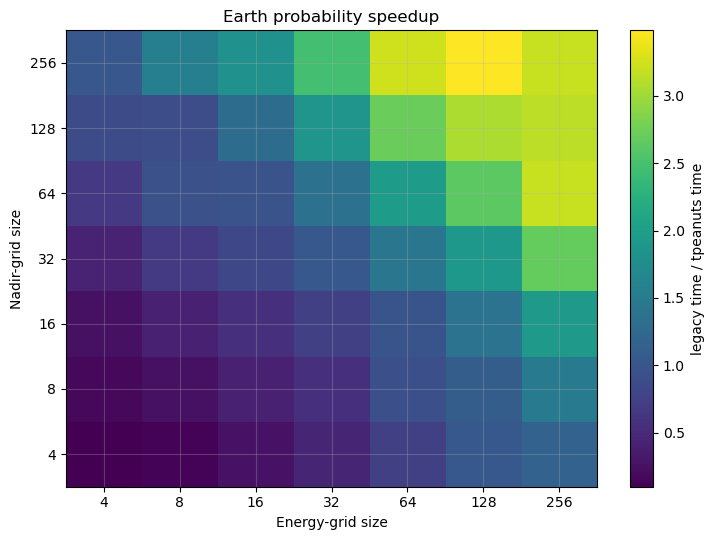

Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\earth_probability_speedup_cross_sections.png


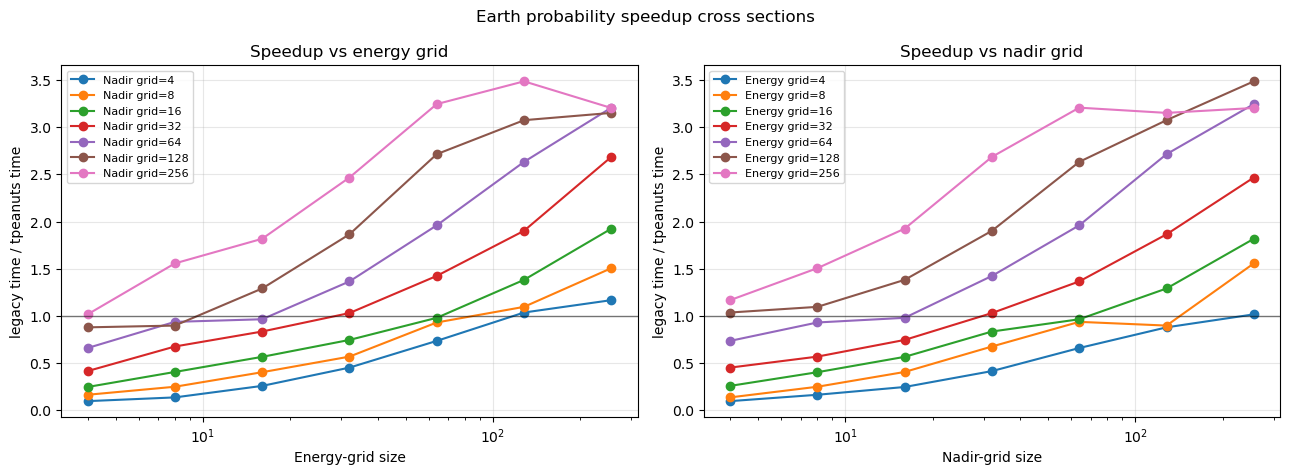

In [10]:
earth_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        earth_probability_records.append(benchmark_pair(
            "earth probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: torch_pearth_probability(MASS_WEIGHTS, E[:, None], eta[None, :], EARTH_DEPTH_M, massbasis=True),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d): np.stack([
                legacy_pearth(MASS_WEIGHTS_NP, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2, float(energy), float(angle), EARTH_DEPTH_M, mode=LEGACY_EARTH_MODE, massbasis=True)
                for energy in E_np for angle in eta_np
            ]).reshape(len(E_np), len(eta_np), 3),
        ))
earth_probability_df = pd.DataFrame(earth_probability_records)
display(earth_probability_df)
save_results(earth_probability_df, "earth_probability_timing")
plot_heatmap(earth_probability_df, "Earth probability speedup", "earth_probability_speedup.png")
plot_speedup_cross_sections(earth_probability_df, "Earth probability speedup cross sections", "earth_probability_speedup_cross_sections.png")


### 5.2 Flux Timing

This subsection times Earth response matrices applied to a synthetic three-component input spectrum.


earth flux                         | NE=   4 | Neta=   4 | t=2.9200e-02s | legacy=3.1288e-03s | speedup=0.11x
earth flux                         | NE=   4 | Neta=   8 | t=2.9515e-02s | legacy=5.1000e-03s | speedup=0.17x
earth flux                         | NE=   4 | Neta=  16 | t=4.0367e-02s | legacy=9.4611e-03s | speedup=0.23x
earth flux                         | NE=   4 | Neta=  32 | t=4.8188e-02s | legacy=1.8373e-02s | speedup=0.38x
earth flux                         | NE=   4 | Neta=  64 | t=6.7610e-02s | legacy=3.7911e-02s | speedup=0.56x
earth flux                         | NE=   4 | Neta= 128 | t=8.9214e-02s | legacy=8.1928e-02s | speedup=0.92x
earth flux                         | NE=   4 | Neta= 256 | t=1.5544e-01s | legacy=1.5841e-01s | speedup=1.02x
earth flux                         | NE=   8 | Neta=   4 | t=3.5912e-02s | legacy=8.9015e-03s | speedup=0.25x
earth flux                         | NE=   8 | Neta=   8 | t=3.6894e-02s | legacy=1.0274e-02s | speedup=0.28x
earth flux

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,earth flux,4,4,0.029200,0.003129,0.030224,0.003279,1.024050e-03,0.000150,0.107152
1,earth flux,4,8,0.029515,0.005100,0.031154,0.005120,1.638950e-03,0.000020,0.172793
2,earth flux,4,16,0.040367,0.009461,0.042889,0.009503,2.522300e-03,0.000042,0.234376
3,earth flux,4,32,0.048188,0.018373,0.048611,0.018688,4.235500e-04,0.000315,0.381280
4,earth flux,4,64,0.067610,0.037911,0.070413,0.038057,2.803350e-03,0.000146,0.560726
5,earth flux,4,128,0.089214,0.081928,0.089832,0.084088,6.183500e-04,0.002161,0.918330
6,earth flux,4,256,0.155441,0.158413,0.156513,0.159514,1.072050e-03,0.001101,1.019122
7,earth flux,8,4,0.035912,0.008902,0.039146,0.009615,3.234350e-03,0.000714,0.247872
8,earth flux,8,8,0.036894,0.010274,0.039109,0.010373,2.215650e-03,0.000099,0.278476
9,earth flux,8,16,0.045504,0.021847,0.049520,0.022843,4.016500e-03,0.000996,0.480110


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\earth_flux_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\earth_flux_speedup.png


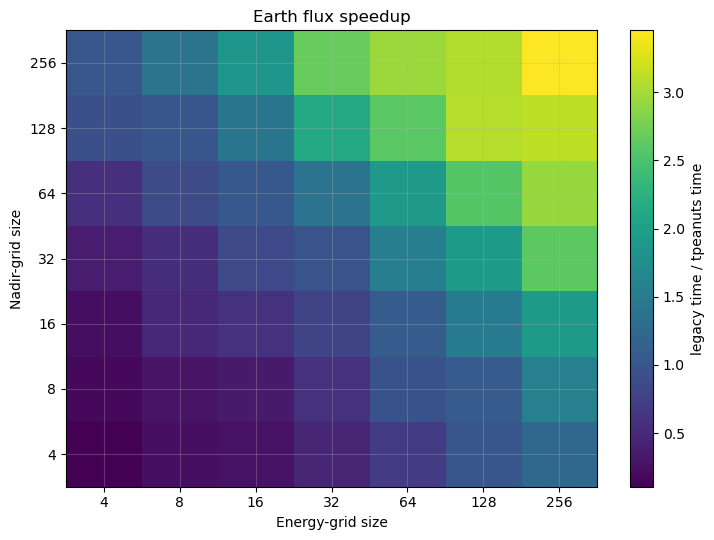

Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\earth_flux_speedup_cross_sections.png


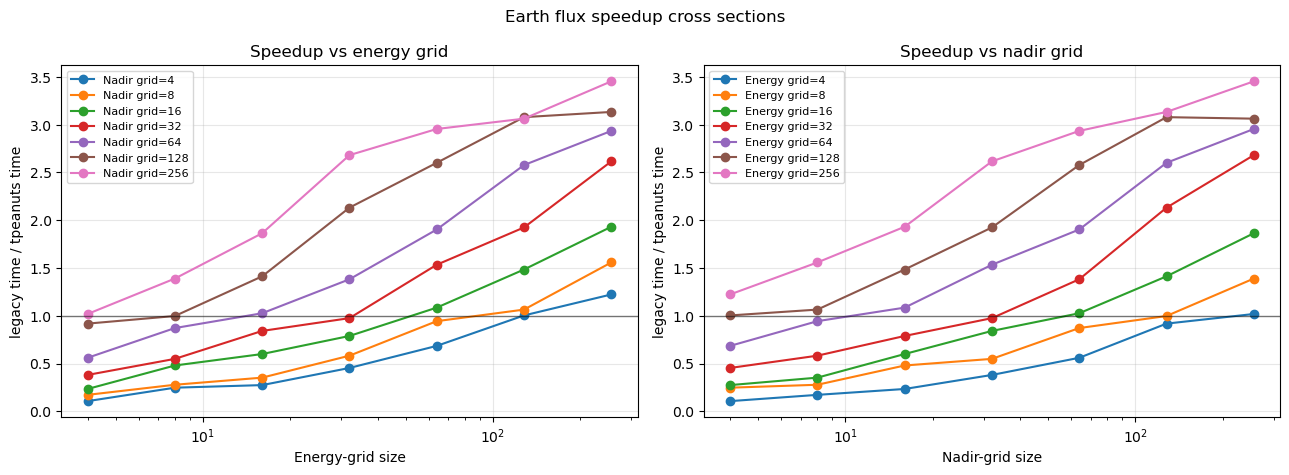

In [11]:
def tpeanuts_earth_flux(E_1d, eta_1d, flux):
    cols = []
    for i in range(3):
        cols.append(torch_pearth_probability(torch.eye(3, dtype=DTYPE, device=DEVICE)[i], E_1d[:, None], eta_1d[None, :], EARTH_DEPTH_M, massbasis=True))
    return torch.einsum("enba,ea->enb", torch.stack(cols, dim=-1), flux)


def legacy_earth_flux(E_np, eta_np, flux_np):
    cols = []
    for i in range(3):
        state = np.eye(3)[i]
        cols.append(np.stack([
            legacy_pearth(state, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2, float(energy), float(angle), EARTH_DEPTH_M, mode=LEGACY_EARTH_MODE, massbasis=True)
            for energy in E_np for angle in eta_np
        ]).reshape(len(E_np), len(eta_np), 3))
    return np.einsum("enba,ea->enb", np.stack(cols, axis=-1), flux_np)


earth_flux_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        flux = synthetic_flux(E_1d)
        earth_flux_records.append(benchmark_pair(
            "earth flux", ne, neta,
            lambda E=E_1d, eta=eta_1d, flux=flux: tpeanuts_earth_flux(E, eta, flux),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d), flux_np=to_numpy(flux): legacy_earth_flux(E_np, eta_np, flux_np),
        ))
earth_flux_df = pd.DataFrame(earth_flux_records)
display(earth_flux_df)
save_results(earth_flux_df, "earth_flux_timing")
plot_heatmap(earth_flux_df, "Earth flux speedup", "earth_flux_speedup.png")
plot_speedup_cross_sections(earth_flux_df, "Earth flux speedup cross sections", "earth_flux_speedup_cross_sections.png")


## 6. Integrated Probabilities

This section times solar production, Earth propagation, and integration over the nadir grid at surface depth.


integrated probabilities           | NE=   4 | Neta=   4 | t=1.2741e-02s | legacy=2.0928e-03s | speedup=0.16x
integrated probabilities           | NE=   4 | Neta=   8 | t=1.1226e-02s | legacy=3.1877e-03s | speedup=0.28x
integrated probabilities           | NE=   4 | Neta=  16 | t=1.4032e-02s | legacy=4.1936e-03s | speedup=0.30x
integrated probabilities           | NE=   4 | Neta=  32 | t=1.7916e-02s | legacy=7.1754e-03s | speedup=0.40x
integrated probabilities           | NE=   4 | Neta=  64 | t=2.2339e-02s | legacy=1.3001e-02s | speedup=0.58x
integrated probabilities           | NE=   4 | Neta= 128 | t=3.0760e-02s | legacy=2.4845e-02s | speedup=0.81x
integrated probabilities           | NE=   4 | Neta= 256 | t=4.8256e-02s | legacy=4.9750e-02s | speedup=1.03x
integrated probabilities           | NE=   8 | Neta=   4 | t=1.5295e-02s | legacy=3.8436e-03s | speedup=0.25x
integrated probabilities           | NE=   8 | Neta=   8 | t=1.4354e-02s | legacy=5.2213e-03s | speedup=0.36x
integrated

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,integrated probabilities,4,4,0.012741,0.002093,0.013084,0.002115,0.000343,0.000022,0.164258
1,integrated probabilities,4,8,0.011226,0.003188,0.012256,0.003831,0.001030,0.000643,0.283952
2,integrated probabilities,4,16,0.014032,0.004194,0.014640,0.004208,0.000608,0.000014,0.298853
3,integrated probabilities,4,32,0.017916,0.007175,0.020414,0.007205,0.002499,0.000030,0.400509
4,integrated probabilities,4,64,0.022339,0.013001,0.022516,0.013159,0.000177,0.000159,0.581961
5,integrated probabilities,4,128,0.030760,0.024845,0.031208,0.028429,0.000448,0.003584,0.807713
6,integrated probabilities,4,256,0.048256,0.049750,0.049229,0.055097,0.000973,0.005347,1.030964
7,integrated probabilities,8,4,0.015295,0.003844,0.015306,0.003915,0.000011,0.000072,0.251293
8,integrated probabilities,8,8,0.014354,0.005221,0.016862,0.005247,0.002508,0.000025,0.363757
9,integrated probabilities,8,16,0.018358,0.008019,0.019009,0.008164,0.000651,0.000145,0.436836


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\integrated_probability_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\integrated_probability_speedup.png


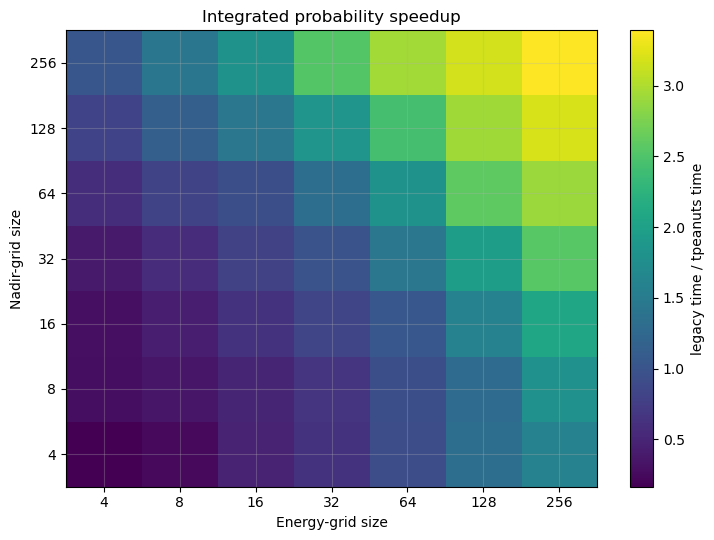

Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\integrated_probability_speedup_cross_sections.png


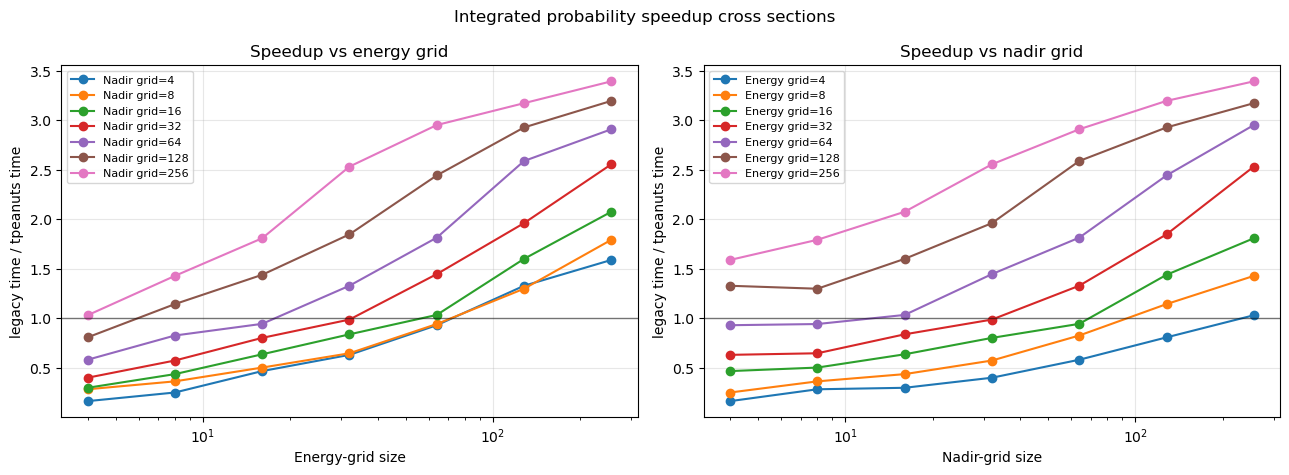

In [12]:
def tpeanuts_integrated(E_1d, eta_1d, depth_m):
    mass = tpeanuts_solar_mass(E_1d)
    P_eta = torch_pearth_probability(mass, E_1d[:, None], eta_1d[None, :], depth_m, massbasis=True)
    exposure = torch.ones_like(eta_1d)
    exposure = exposure / torch.trapezoid(exposure, x=eta_1d).clamp_min(torch.finfo(DTYPE).tiny)
    return torch.trapezoid(P_eta * exposure[None, :, None], x=eta_1d, dim=1)


def legacy_integrated(E_np, eta_np, depth_m):
    exposure = np.ones_like(eta_np, dtype=np.float64)
    exposure = exposure / max(np.trapz(exposure, x=eta_np), np.finfo(float).tiny)
    rows = []
    for energy in E_np:
        mass = legacy_solar_mass(np.array([energy]))[0]
        P_eta = np.stack([
            legacy_pearth(mass, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2, float(energy), float(angle), depth_m, mode=LEGACY_EARTH_MODE, massbasis=True)
            for angle in eta_np
        ])
        rows.append(np.trapz(P_eta * exposure[:, None], x=eta_np, axis=0))
    return np.stack(rows)


integrated_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        integrated_probability_records.append(benchmark_pair(
            "integrated probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_integrated(E, eta, EARTH_DEPTH_M),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d): legacy_integrated(E_np, eta_np, EARTH_DEPTH_M),
        ))
integrated_probability_df = pd.DataFrame(integrated_probability_records)
display(integrated_probability_df)
save_results(integrated_probability_df, "integrated_probability_timing")
plot_heatmap(integrated_probability_df, "Integrated probability speedup", "integrated_probability_speedup.png")
plot_speedup_cross_sections(integrated_probability_df, "Integrated probability speedup cross sections", "integrated_probability_speedup_cross_sections.png")


## 7. Solar-Detector

This final section times the complete chain from solar production to a detector at 1000 m depth.


### 7.1 Probability Timing

This subsection times full solar-detector probabilities over both grids.


solar-detector probabilities       | NE=   4 | Neta=   4 | t=1.6864e-02s | legacy=1.9187e-03s | speedup=0.11x
solar-detector probabilities       | NE=   4 | Neta=   8 | t=1.8451e-02s | legacy=2.6837e-03s | speedup=0.15x
solar-detector probabilities       | NE=   4 | Neta=  16 | t=2.0018e-02s | legacy=4.3167e-03s | speedup=0.22x
solar-detector probabilities       | NE=   4 | Neta=  32 | t=2.5912e-02s | legacy=7.7267e-03s | speedup=0.30x
solar-detector probabilities       | NE=   4 | Neta=  64 | t=2.9705e-02s | legacy=1.4262e-02s | speedup=0.48x
solar-detector probabilities       | NE=   4 | Neta= 128 | t=3.9235e-02s | legacy=2.8208e-02s | speedup=0.72x
solar-detector probabilities       | NE=   4 | Neta= 256 | t=6.0042e-02s | legacy=5.4069e-02s | speedup=0.90x
solar-detector probabilities       | NE=   8 | Neta=   4 | t=1.9749e-02s | legacy=3.6474e-03s | speedup=0.18x
solar-detector probabilities       | NE=   8 | Neta=   8 | t=2.1472e-02s | legacy=5.0916e-03s | speedup=0.24x
solar-dete

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar-detector probabilities,4,4,0.016864,0.001919,0.017214,0.001940,0.000350,0.000021,0.113778
1,solar-detector probabilities,4,8,0.018451,0.002684,0.018587,0.002905,0.000136,0.000221,0.145452
2,solar-detector probabilities,4,16,0.020018,0.004317,0.020865,0.004339,0.000847,0.000022,0.215641
3,solar-detector probabilities,4,32,0.025912,0.007727,0.026068,0.007767,0.000156,0.000040,0.298193
4,solar-detector probabilities,4,64,0.029705,0.014262,0.029945,0.014905,0.000240,0.000643,0.480118
5,solar-detector probabilities,4,128,0.039235,0.028208,0.039649,0.028248,0.000414,0.000040,0.718956
6,solar-detector probabilities,4,256,0.060042,0.054069,0.060892,0.054384,0.000850,0.000315,0.900513
7,solar-detector probabilities,8,4,0.019749,0.003647,0.020850,0.003678,0.001101,0.000030,0.184685
8,solar-detector probabilities,8,8,0.021472,0.005092,0.021736,0.005129,0.000265,0.000037,0.237129
9,solar-detector probabilities,8,16,0.023488,0.008446,0.025289,0.008615,0.001801,0.000168,0.359601


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_probability_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_probability_speedup.png


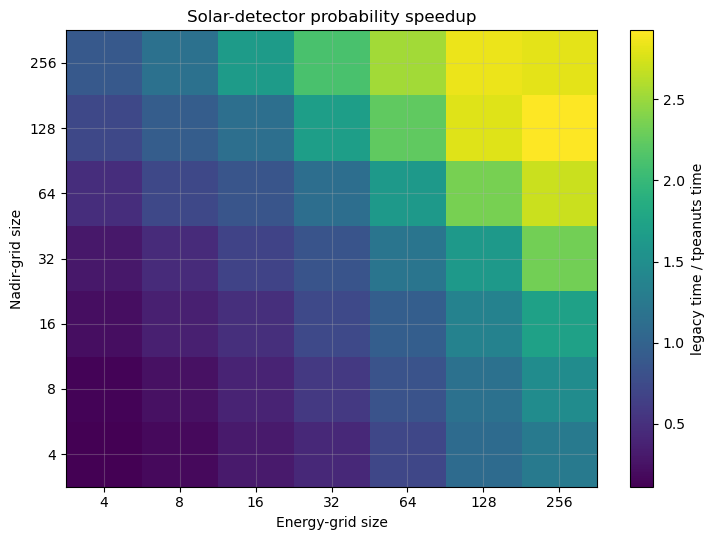

Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_probability_speedup_cross_sections.png


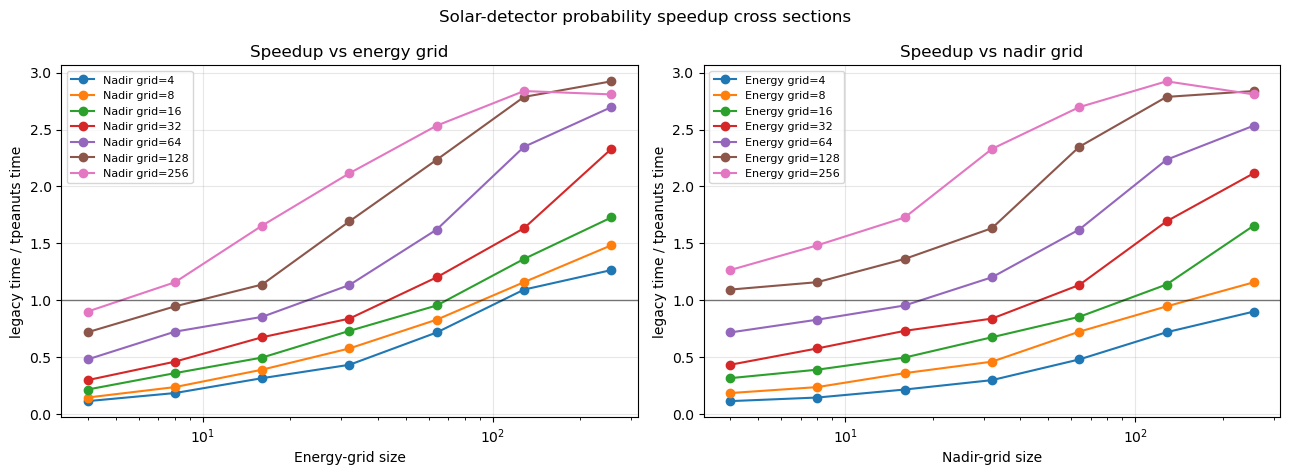

In [13]:
def tpeanuts_solar_detector_probabilities(E_1d, eta_1d):
    mass = tpeanuts_solar_mass(E_1d)
    return torch_pearth_probability(mass, E_1d[:, None], eta_1d[None, :], SOLAR_DETECTOR_DEPTH_M, massbasis=True)


def legacy_solar_detector_probabilities(E_np, eta_np):
    rows = []
    for energy in E_np:
        mass = legacy_solar_mass(np.array([energy]))[0]
        rows.append(np.stack([
            legacy_pearth(mass, earth_density_l, legacy_pmns, DM21_EV2, DM3L_EV2, float(energy), float(angle), SOLAR_DETECTOR_DEPTH_M, mode=LEGACY_EARTH_MODE, massbasis=True)
            for angle in eta_np
        ]))
    return np.stack(rows)


solar_detector_probability_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        solar_detector_probability_records.append(benchmark_pair(
            "solar-detector probabilities", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_solar_detector_probabilities(E, eta),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d): legacy_solar_detector_probabilities(E_np, eta_np),
        ))
solar_detector_probability_df = pd.DataFrame(solar_detector_probability_records)
display(solar_detector_probability_df)
save_results(solar_detector_probability_df, "solar_detector_probability_timing")
plot_heatmap(solar_detector_probability_df, "Solar-detector probability speedup", "solar_detector_probability_speedup.png")
plot_speedup_cross_sections(solar_detector_probability_df, "Solar-detector probability speedup cross sections", "solar_detector_probability_speedup_cross_sections.png")


### 7.2 Flux Timing

This subsection times the full solar-detector calculation plus multiplication by a source spectrum.


solar-detector flux                | NE=   4 | Neta=   4 | t=1.6655e-02s | legacy=1.9592e-03s | speedup=0.12x
solar-detector flux                | NE=   4 | Neta=   8 | t=1.8983e-02s | legacy=2.6616e-03s | speedup=0.14x
solar-detector flux                | NE=   4 | Neta=  16 | t=2.0619e-02s | legacy=4.4458e-03s | speedup=0.22x
solar-detector flux                | NE=   4 | Neta=  32 | t=2.5086e-02s | legacy=7.8329e-03s | speedup=0.31x
solar-detector flux                | NE=   4 | Neta=  64 | t=2.8160e-02s | legacy=1.4371e-02s | speedup=0.51x
solar-detector flux                | NE=   4 | Neta= 128 | t=3.9100e-02s | legacy=2.7428e-02s | speedup=0.70x
solar-detector flux                | NE=   4 | Neta= 256 | t=6.1562e-02s | legacy=5.4000e-02s | speedup=0.88x
solar-detector flux                | NE=   8 | Neta=   4 | t=1.9785e-02s | legacy=3.7376e-03s | speedup=0.19x
solar-detector flux                | NE=   8 | Neta=   8 | t=2.2023e-02s | legacy=5.1509e-03s | speedup=0.23x
solar-dete

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar-detector flux,4,4,0.016655,0.001959,0.017758,0.001962,0.001103,0.000003,0.117638
1,solar-detector flux,4,8,0.018983,0.002662,0.020663,0.002679,0.001680,0.000018,0.140210
2,solar-detector flux,4,16,0.020619,0.004446,0.021602,0.004561,0.000983,0.000115,0.215620
3,solar-detector flux,4,32,0.025086,0.007833,0.027142,0.007920,0.002057,0.000087,0.312248
4,solar-detector flux,4,64,0.028160,0.014371,0.028401,0.014754,0.000242,0.000383,0.510352
5,solar-detector flux,4,128,0.039100,0.027428,0.039470,0.027454,0.000371,0.000026,0.701487
6,solar-detector flux,4,256,0.061562,0.054000,0.063603,0.058059,0.002040,0.004059,0.877159
7,solar-detector flux,8,4,0.019785,0.003738,0.020256,0.004043,0.000471,0.000305,0.188908
8,solar-detector flux,8,8,0.022023,0.005151,0.023047,0.005250,0.001024,0.000100,0.233882
9,solar-detector flux,8,16,0.027734,0.008345,0.028120,0.008357,0.000386,0.000012,0.300908


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_flux_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_flux_speedup.png


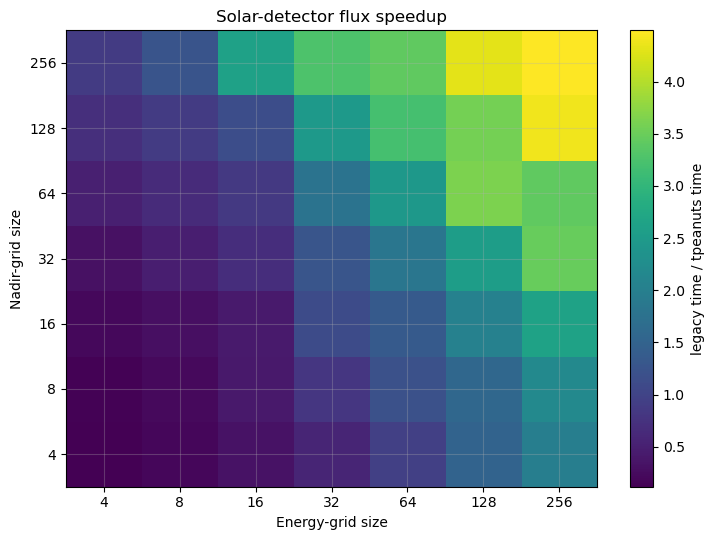

Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_flux_speedup_cross_sections.png


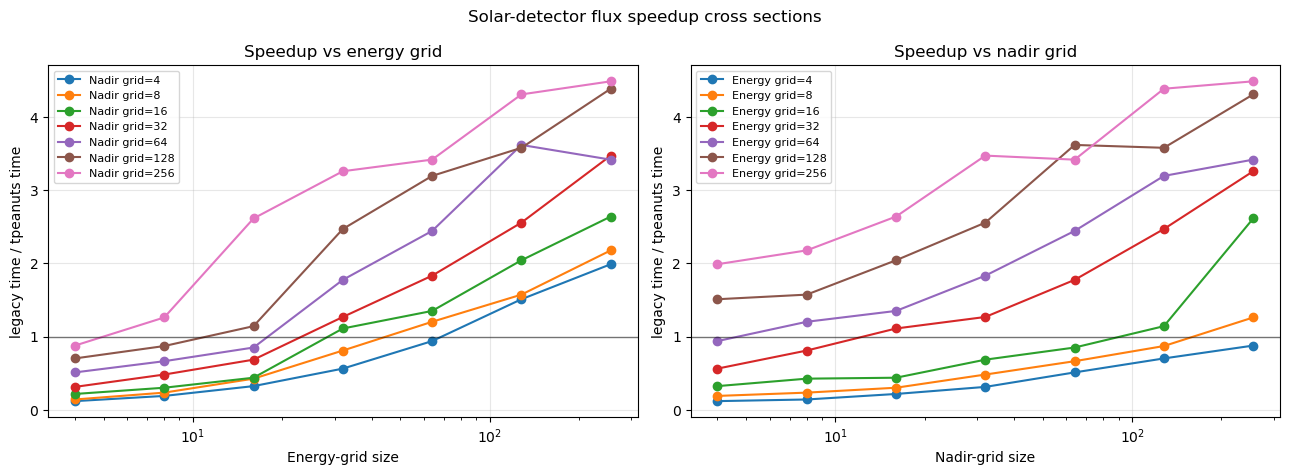

In [14]:
solar_detector_flux_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        spectrum_t = solar_source_spectrum(E_1d)
        spectrum_l = to_numpy(spectrum_t)
        solar_detector_flux_records.append(benchmark_pair(
            "solar-detector flux", ne, neta,
            lambda E=E_1d, eta=eta_1d, spectrum=spectrum_t: tpeanuts_solar_detector_probabilities(E, eta) * spectrum[:, None, None],
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d), spectrum=spectrum_l: legacy_solar_detector_probabilities(E_np, eta_np) * spectrum[:, None, None],
        ))
solar_detector_flux_df = pd.DataFrame(solar_detector_flux_records)
display(solar_detector_flux_df)
save_results(solar_detector_flux_df, "solar_detector_flux_timing")
plot_heatmap(solar_detector_flux_df, "Solar-detector flux speedup", "solar_detector_flux_speedup.png")
plot_speedup_cross_sections(solar_detector_flux_df, "Solar-detector flux speedup cross sections", "solar_detector_flux_speedup_cross_sections.png")


### 7.3 Integrated Probability Timing

This subsection integrates complete solar-detector probabilities over the nadir grid.


solar-detector integrated          | NE=   4 | Neta=   4 | t=1.9289e-02s | legacy=3.3599e-03s | speedup=0.17x
solar-detector integrated          | NE=   4 | Neta=   8 | t=1.9337e-02s | legacy=4.2673e-03s | speedup=0.22x
solar-detector integrated          | NE=   4 | Neta=  16 | t=2.0952e-02s | legacy=6.7150e-03s | speedup=0.32x
solar-detector integrated          | NE=   4 | Neta=  32 | t=2.5032e-02s | legacy=1.2497e-02s | speedup=0.50x
solar-detector integrated          | NE=   4 | Neta=  64 | t=3.0039e-02s | legacy=2.2302e-02s | speedup=0.74x
solar-detector integrated          | NE=   4 | Neta= 128 | t=3.8715e-02s | legacy=4.2967e-02s | speedup=1.11x
solar-detector integrated          | NE=   4 | Neta= 256 | t=6.8961e-02s | legacy=8.8193e-02s | speedup=1.28x
solar-detector integrated          | NE=   8 | Neta=   4 | t=1.9447e-02s | legacy=5.7410e-03s | speedup=0.30x
solar-detector integrated          | NE=   8 | Neta=   8 | t=2.1988e-02s | legacy=8.0898e-03s | speedup=0.37x
solar-dete

,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,solar-detector integrated,4,4,0.019289,0.003360,0.019798,0.003438,0.000509,0.000079,0.174187
1,solar-detector integrated,4,8,0.019337,0.004267,0.021193,0.004452,0.001857,0.000185,0.220684
2,solar-detector integrated,4,16,0.020952,0.006715,0.021235,0.006987,0.000283,0.000272,0.320499
3,solar-detector integrated,4,32,0.025032,0.012497,0.025186,0.012548,0.000154,0.000051,0.499245
4,solar-detector integrated,4,64,0.030039,0.022302,0.036281,0.023024,0.006242,0.000722,0.742449
5,solar-detector integrated,4,128,0.038715,0.042967,0.041306,0.043771,0.002591,0.000804,1.109844
6,solar-detector integrated,4,256,0.068961,0.088193,0.073259,0.089760,0.004298,0.001567,1.278876
7,solar-detector integrated,8,4,0.019447,0.005741,0.022537,0.005754,0.003090,0.000013,0.295213
8,solar-detector integrated,8,8,0.021988,0.008090,0.023380,0.008313,0.001392,0.000223,0.367919
9,solar-detector integrated,8,16,0.027108,0.015219,0.027914,0.015678,0.000806,0.000460,0.561421


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_integrated_timing.csv
Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_integrated_speedup.png


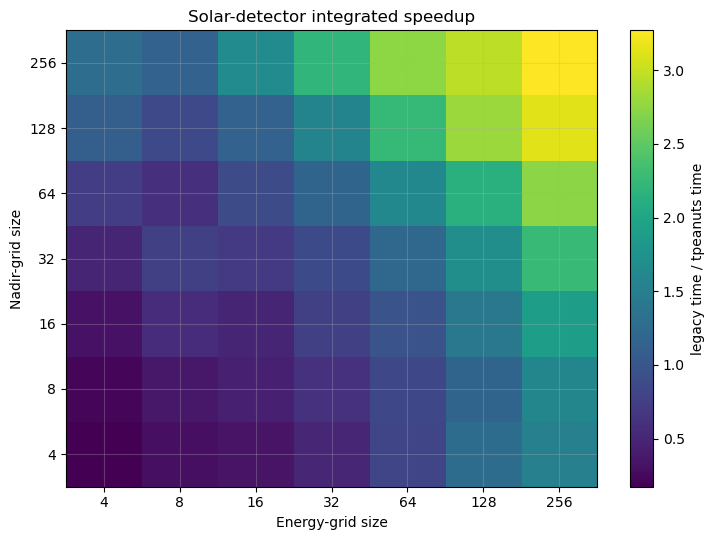

Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\solar_detector_integrated_speedup_cross_sections.png


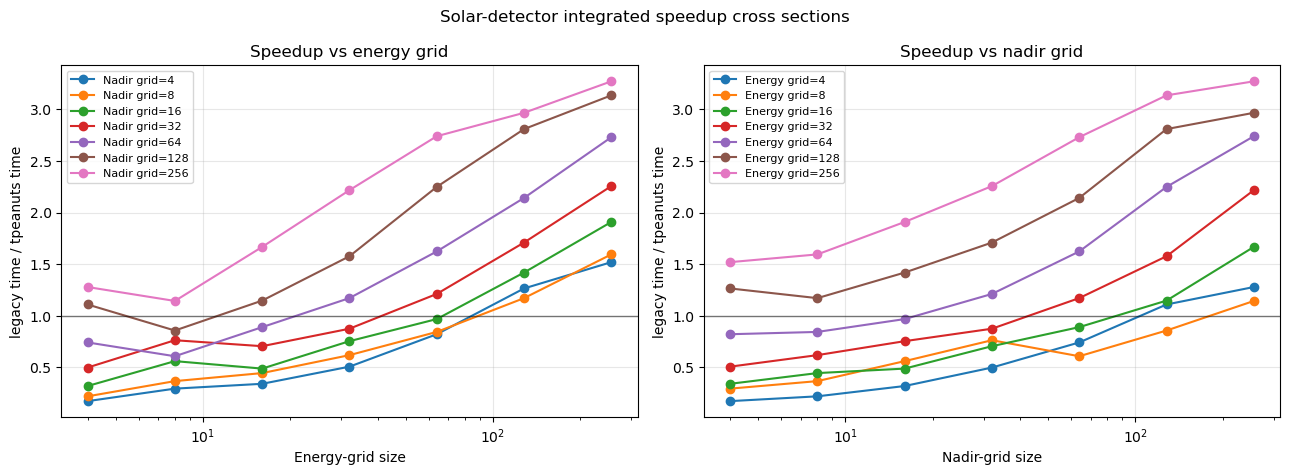

In [15]:
solar_detector_integrated_records = []
for ne in ENERGY_GRID_SIZES:
    for neta in NADIR_GRID_SIZES:
        E_1d = energy_grid(ne, solar=True)
        eta_1d = nadir_grid(neta)
        solar_detector_integrated_records.append(benchmark_pair(
            "solar-detector integrated", ne, neta,
            lambda E=E_1d, eta=eta_1d: tpeanuts_integrated(E, eta, SOLAR_DETECTOR_DEPTH_M),
            lambda E_np=to_numpy(E_1d), eta_np=to_numpy(eta_1d): legacy_integrated(E_np, eta_np, SOLAR_DETECTOR_DEPTH_M),
        ))
solar_detector_integrated_df = pd.DataFrame(solar_detector_integrated_records)
display(solar_detector_integrated_df)
save_results(solar_detector_integrated_df, "solar_detector_integrated_timing")
plot_heatmap(solar_detector_integrated_df, "Solar-detector integrated speedup", "solar_detector_integrated_speedup.png")
plot_speedup_cross_sections(solar_detector_integrated_df, "Solar-detector integrated speedup cross sections", "solar_detector_integrated_speedup_cross_sections.png")


## 8. Summary

The final table concatenates every timing result and stores a combined CSV.


,section,n_energy,n_nadir,tpeanuts_best_s,legacy_best_s,tpeanuts_mean_s,legacy_mean_s,tpeanuts_std_s,legacy_std_s,speedup_legacy_over_tpeanuts
0,vacuum probabilities,4,None,0.001051,0.000773,0.001085,0.000877,0.000034,0.000104,0.735185
1,vacuum probabilities,8,None,0.001053,0.001438,0.001231,0.003273,0.000179,0.001835,1.366141
2,vacuum probabilities,16,None,0.001057,0.002367,0.001473,0.002502,0.000416,0.000135,2.240488
3,vacuum probabilities,32,None,0.001193,0.004784,0.001896,0.005619,0.000703,0.000835,4.008631
4,vacuum probabilities,64,None,0.001236,0.008611,0.001748,0.008737,0.000512,0.000126,6.968277
...,...,...,...,...,...,...,...,...,...,...
317,solar-detector integrated,256,16,0.145316,0.277361,0.152255,0.278425,0.006939,0.001064,1.908680
318,solar-detector integrated,256,32,0.217167,0.489931,0.222568,0.497168,0.005401,0.007238,2.256012
319,solar-detector integrated,256,64,0.331031,0.903465,0.343867,0.913889,0.012836,0.010424,2.729244
320,solar-detector integrated,256,128,0.570753,1.789005,0.579769,1.804392,0.009016,0.015387,3.134461


Saved timing table: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\all_performance_timing.csv


,section,median_speedup,min_speedup,max_speedup
9,vacuum probabilities,4.008631,0.735185,28.354927
8,vacuum flux,3.669231,0.654246,20.739970
5,solar-detector flux,1.261800,0.117638,4.490328
6,solar-detector integrated,1.143983,0.174187,3.270298
2,integrated probabilities,1.143553,0.164258,3.391797
1,earth probabilities,1.031573,0.098756,3.485863
0,earth flux,1.026805,0.107152,3.454058
7,solar-detector probabilities,0.954118,0.113778,2.923219
4,solar probabilities,0.622275,0.274195,1.807948
3,solar flux,0.557616,0.320470,1.887446


Saved figure: V:\output\benchmark\1_tpeanuts_vs_peanuts_performance\summary_max_speedup.png


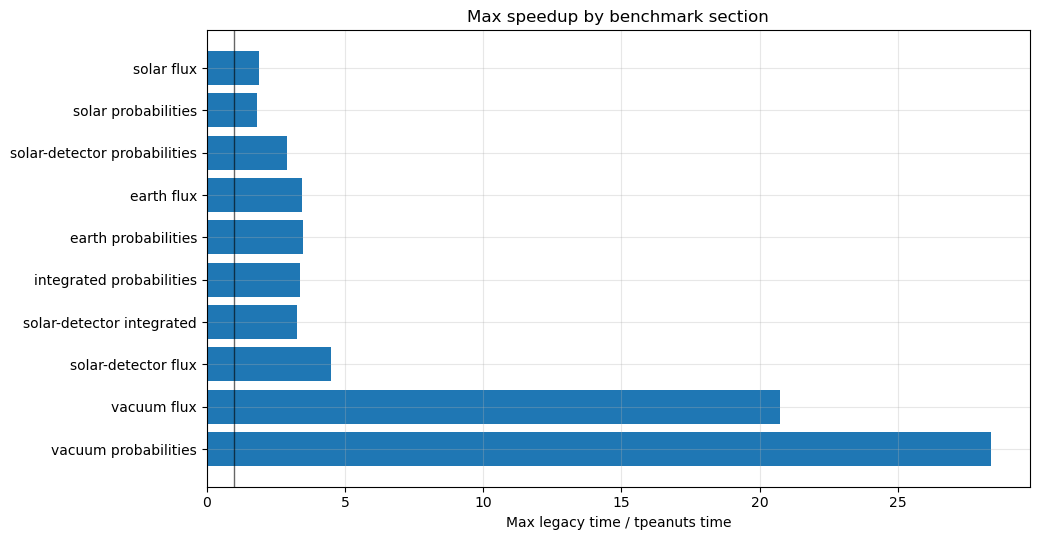

WindowsPath('V:/output/benchmark/1_tpeanuts_vs_peanuts_performance/summary_max_speedup.png')

In [16]:
all_timing_df = pd.concat([
    vacuum_probability_df,
    vacuum_flux_df,
    solar_probability_df,
    solar_flux_df,
    earth_probability_df,
    earth_flux_df,
    integrated_probability_df,
    solar_detector_probability_df,
    solar_detector_flux_df,
    solar_detector_integrated_df,
], ignore_index=True)
display(all_timing_df)
save_results(all_timing_df, "all_performance_timing")

summary = (
    all_timing_df.groupby("section", as_index=False)
    .agg(
        median_speedup=("speedup_legacy_over_tpeanuts", "median"),
        min_speedup=("speedup_legacy_over_tpeanuts", "min"),
        max_speedup=("speedup_legacy_over_tpeanuts", "max"),
    )
    .sort_values("median_speedup", ascending=False)
)
display(summary)

fig, ax = plt.subplots(figsize=(10.5, 5.5))
ax.barh(summary["section"], summary["max_speedup"])
ax.axvline(1.0, color="black", lw=1.0, alpha=0.6)
ax.set_xlabel("Max legacy time / tpeanuts time")
ax.set_title("Max speedup by benchmark section")
fig.tight_layout()
save_and_show("summary_max_speedup.png", fig, output_dir=OUTPUT_DIR, show_plots=SHOW_PLOTS)
